# EDA - Análise Exploratória de Dados

Dataset: `dataset_2k.csv`

## Configuração e Importação das Bibliotecas

In [ ]:
#Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

In [ ]:
#Configurações de visualização
PALETTE = {
    1: "#2a78d6",  # blue
    2: "#eb6834",  # orange
    3: "#1baf7a",  # aqua
    4: "#eda100",  # yellow
    5: "#e87ba4",  # magenta
    6: "#008300",  # green
    7: "#4a3aa7",  # violet
    8: "#e34948",  # red
}
CAT_ORDER = [PALETTE[i] for i in range(1, 9)]

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

DIVERGE_NEG = PALETTE[1]   # blue
DIVERGE_POS = PALETTE[8]   # red
DIVERGE_MID = "#f0efec"  # gray 

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "axes.titlecolor": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRID,
    "text.color": INK_PRIMARY,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_style("whitegrid", {"axes.facecolor": SURFACE, "grid.color": GRID})

## Leitura dos Dados

In [ ]:
df = pd.read_csv("data/dataset_2k.csv", sep=",")
df.head()

,cliente_id,idade,renda_mensal,gasto_mensal,frequencia_compra,ticket_medio,tempo_cliente_anos,score_engajamento,canal,regiao,plano,data_cadastro,segmento_latente
0,1,36.0,8535.39,765.48,2.8,270.00,10.8,9.5,Site,Sudeste,Básico,2024-12-27,Tradicional
1,2,39.0,6828.45,719.92,3.8,187.13,8.7,23.3,Aplicativo,Sudeste,Básico,2024-04-13,Tradicional
2,3,47.0,11858.51,3872.77,9.0,431.74,13.8,39.8,Marketplace,Centro-Oeste,Premium,2026-04-07,Alto valor
3,4,43.0,5712.55,781.26,6.4,121.43,5.9,49.3,Site,Nordeste,Premium,2026-05-16,Tradicional
4,5,25.0,4324.94,1391.81,15.2,91.32,1.5,48.8,Aplicativo,Sul,Premium,2024-01-20,Jovem digital


## Visão geral do dataset

In [ ]:
#Informações gerais do dataset
print("Shape:", df.shape)
df.info()

Shape: (2000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          2000 non-null   int64  
 1   idade               2000 non-null   float64
 2   renda_mensal        2000 non-null   float64
 3   gasto_mensal        2000 non-null   float64
 4   frequencia_compra   2000 non-null   float64
 5   ticket_medio        2000 non-null   float64
 6   tempo_cliente_anos  2000 non-null   float64
 7   score_engajamento   2000 non-null   float64
 8   canal               2000 non-null   str    
 9   regiao              2000 non-null   str    
 10  plano               2000 non-null   str    
 11  data_cadastro       2000 non-null   str    
 12  segmento_latente    2000 non-null   str    
dtypes: float64(7), int64(1), str(5)
memory usage: 203.3 KB


In [ ]:
#Verificando valores nulos
df.isna().sum().to_frame("nulos")

,nulos
cliente_id,0
idade,0
renda_mensal,0
gasto_mensal,0
frequencia_compra,0
ticket_medio,0
tempo_cliente_anos,0
score_engajamento,0
canal,0
regiao,0


In [ ]:
#Verificando duplicatas
print("Linhas duplicadas:", df.duplicated().sum())
print("cliente_id duplicados:", df['cliente_id'].duplicated().sum())

Linhas duplicadas: 0
cliente_id duplicados: 0


* A base tem 2000 clientes e 13 colunas;
* Não tem nenhum valor ausente e sem linhas ou `cliente_id` duplicados.

Não há necessidade de imputação nem deduplicação antes de seguir com a análise.

In [ ]:
#Verificando estatísticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cliente_id,2000.0,1000.50000,577.494589,1.00,500.75,1000.500,1500.2500,2000.00
idade,2000.0,38.27500,11.548726,18.00,28.00,38.000,48.0000,73.00
renda_mensal,2000.0,7887.73014,5251.935764,1684.33,4352.45,5990.325,9461.2525,37051.72
gasto_mensal,2000.0,1845.97861,1442.523697,184.23,880.66,1286.100,1915.2825,7954.77
frequencia_compra,2000.0,8.09415,3.384146,1.00,5.40,7.900,10.6000,19.60
ticket_medio,2000.0,250.33477,210.139267,44.22,123.99,157.195,318.9550,3285.62
tempo_cliente_anos,2000.0,7.06275,2.688656,0.10,5.20,7.000,8.8250,18.00
score_engajamento,2000.0,32.73420,12.601031,-13.40,24.10,32.800,41.1000,80.20


In [ ]:
#Verificando estatísticas descritivas para variáveis categóricas
df.describe(include=['object', 'str']).T

,count,unique,top,freq
canal,2000,4,Aplicativo,724
regiao,2000,5,Sudeste,897
plano,2000,3,Básico,1059
data_cadastro,2000,1140,2024-06-21,7
segmento_latente,2000,3,Jovem digital,789


Os valores variam entre:

* **Idade**: 18 a 73 anos;
* **Renda mensal**: R$ 1.684,33 a R$ 37.051,72;
* **Gasto mensal**: R$ 184,23 a R$ 7.954,77;
* **Frequência de compra**: 1,0 a 19,6 compras por mês;
* **Ticket médio**: R$ 44,22 a R$ 3.285,62;
* **Tempo como cliente**: 0,1 a 18,0 anos;
* **Score de engajamento**: -13,4 a 80,2.

Os valores estão dentro de faixas esperadas, a única que chama atenção é o score de engajamento, que admite valores negativos (mínimo -13,4). 

## Ajuste de tipos de dados (dtypes)


In [ ]:
#Idade
df['idade'] = df['idade'].astype('int64')

#Data de cadastro
df['data_cadastro'] = pd.to_datetime(df['data_cadastro'])
print("Período coberto:", df['data_cadastro'].min().date(), "a", df['data_cadastro'].max().date())
df['data_cadastro'].dtype

#Variáveis categóricas de baixa cardinalidade 
colunas_cat = ['canal', 'regiao', 'plano', 'segmento_latente']
for col in colunas_cat:
    df[col] = df[col].astype('category')

df.info()

Período coberto: 2022-01-02 a 2026-07-30
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cliente_id          2000 non-null   int64         
 1   idade               2000 non-null   int64         
 2   renda_mensal        2000 non-null   float64       
 3   gasto_mensal        2000 non-null   float64       
 4   frequencia_compra   2000 non-null   float64       
 5   ticket_medio        2000 non-null   float64       
 6   tempo_cliente_anos  2000 non-null   float64       
 7   score_engajamento   2000 non-null   float64       
 8   canal               2000 non-null   category      
 9   regiao              2000 non-null   category      
 10  plano               2000 non-null   category      
 11  data_cadastro       2000 non-null   datetime64[us]
 12  segmento_latente    2000 non-null   category      
dtypes: category(4), da

## 1. Qual é o perfil de idade?

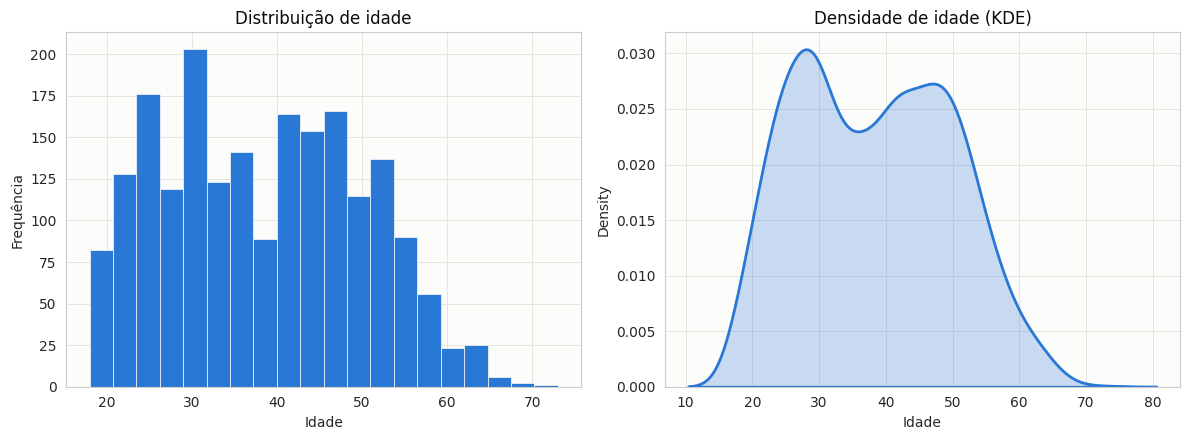

In [ ]:
#Histograma e KDE da variável idade
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['idade'], bins=20, color=PALETTE[1], edgecolor=SURFACE, linewidth=0.5)
axes[0].set_title('Distribuição de idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')

sns.kdeplot(df['idade'], ax=axes[1], color=PALETTE[1], fill=True, alpha=0.25, linewidth=2)
axes[1].set_title('Densidade de idade (KDE)')
axes[1].set_xlabel('Idade')

plt.tight_layout()
plt.show()

A distribuição é *bimodal*, a densidade mostra um pico por volta dos 28 anos e outro por volta dos 47 anos, sugerindo a presença de diferentes perfis de clientes por faixa etária.

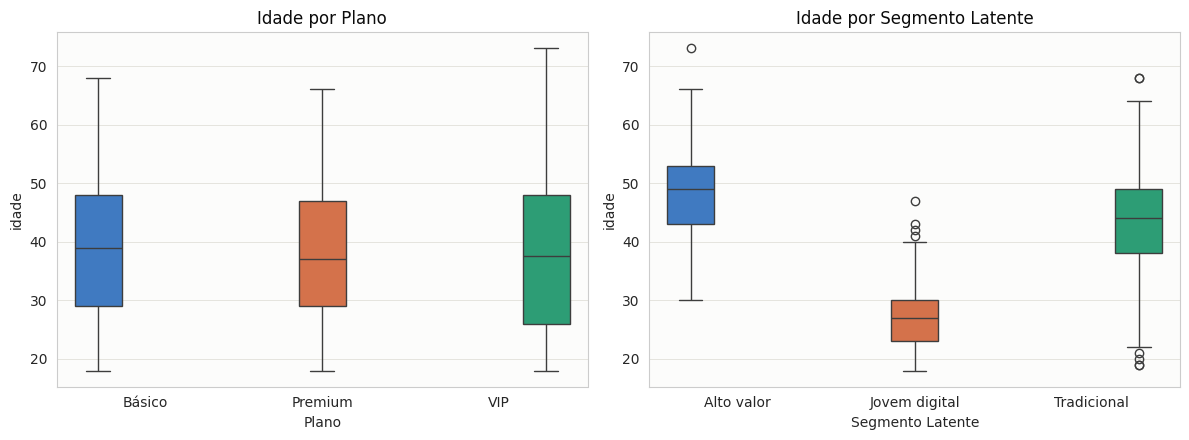

In [ ]:
plano_order = sorted(df['plano'].unique())
seg_order = sorted(df['segmento_latente'].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(
    data=df,
    x='plano',
    y='idade',
    order=plano_order,
    ax=axes[0],
    hue='plano',
    palette=CAT_ORDER[:len(plano_order)],
    legend=False
)

axes[0].set_title('Idade por Plano')
axes[0].set_xlabel('Plano')

sns.boxplot(
    data=df,
    x='segmento_latente',
    y='idade',
    order=seg_order,
    ax=axes[1],
    hue='segmento_latente',
    palette=CAT_ORDER[:len(seg_order)],
    legend=False
)

axes[1].set_title('Idade por Segmento Latente')
axes[1].set_xlabel('Segmento Latente')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print(df.groupby('plano')['idade'].agg(['mean','median','std']).round(2))
print()
print(df.groupby('segmento_latente')['idade'].agg(['mean','median','std']).round(2))

          mean  median    std
plano                        
Básico   38.54    39.0  11.43
Premium  38.04    37.0  11.37
VIP      37.76    37.5  12.64

                   mean  median   std
segmento_latente                     
Alto valor        48.61    49.0  7.40
Jovem digital     27.05    27.0  4.97
Tradicional       43.75    44.0  8.25


* A idade é semelhante entre os diferentes planos, mas varia bastante entre os segmentos. 
* O Jovem Digital tem média de 27,1 anos, o Tradicional 43,8 e o Alto Valor 48,6. 

Portanto, o segmento é mais relevante que o plano para explicar o perfil etário dos clientes.

## 2. Existem rendas extremamente altas?

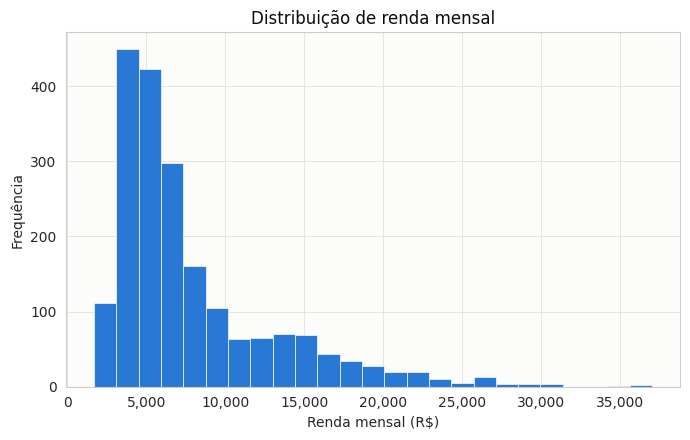

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.hist(
    df['renda_mensal'],
    bins=25,
    color=PALETTE[1],
    edgecolor=SURFACE,
    linewidth=0.5
)

plt.title('Distribuição de renda mensal')
plt.xlabel('Renda mensal (R$)')
plt.ylabel('Frequência')

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.tight_layout()
plt.show()

Com base no gráfico, é possivel visualizar uma cauda longa à direita, sugerindo a presença de rendas muito altas em relação à maioria dos clientes.

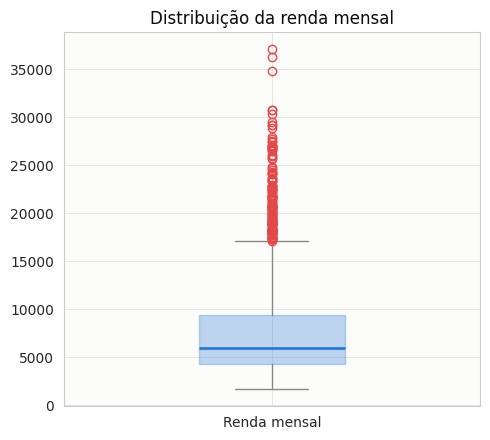

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.boxplot(df['renda_mensal'], vert=True, patch_artist=True, widths=0.35,
           boxprops=dict(facecolor=PALETTE[1], alpha=0.3, edgecolor=PALETTE[1]),
           medianprops=dict(color=PALETTE[1], linewidth=2),
           whiskerprops=dict(color=INK_MUTED),
           capprops=dict(color=INK_MUTED),
           flierprops=dict(markeredgecolor=PALETTE[8], markersize=6))
ax.set_xticklabels(['Renda mensal'])
ax.set_title('Distribuição da renda mensal')
plt.tight_layout()
plt.show()

In [ ]:
q1 = df['renda_mensal'].quantile(0.25)
q3 = df['renda_mensal'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_iqr = df[(df['renda_mensal'] < limite_inferior) | (df['renda_mensal'] > limite_superior)]

print("Resultados do IQR:")
print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
print(f"Limite inferior={limite_inferior:.2f}  Limite superior={limite_superior:.2f}")
print(f"Nº de outliers (IQR): {len(outliers_iqr)} ({100*len(outliers_iqr)/len(df):.1f}% da base)")

df['zscore_renda'] = stats.zscore(df['renda_mensal'])
outliers_z = df[df['zscore_renda'].abs() > 3]
print(f"Nº de outliers (|z| > 3): {len(outliers_z)}")

print()
print("Outliers por plano:")
print(outliers_iqr['plano'].value_counts())
print()
print("Outliers por segmento_latente:")
print(outliers_iqr['segmento_latente'].value_counts())

Resultados do IQR:
Q1=4352.45  Q3=9461.25  IQR=5108.80
Limite inferior=-3310.75  Limite superior=17124.46
Nº de outliers (IQR): 143 (7.2% da base)
Nº de outliers (|z| > 3): 36

Outliers por plano:
plano
Básico     74
Premium    51
VIP        18
Name: count, dtype: int64

Outliers por segmento_latente:
segmento_latente
Alto valor       143
Jovem digital      0
Tradicional        0
Name: count, dtype: int64


* Pelo critério do IQR, 143 clientes foram identificados como outliers, com renda acima de R$ 17.124.
Esses clientes representam 7,2% da base, indicando uma concentração relevante de rendas elevadas;

* Todos os 143 outliers pertencem ao segmento “Alto valor”, mas eles representam apenas 31% desse segmento. Ou seja, nem todo cliente “Alto valor” possui uma renda considerada outlier;

* Os outliers aparecem nos três planos: Básico (74), Premium (51) e VIP (18). Isso mostra que a renda alta não está restrita a um único plano.

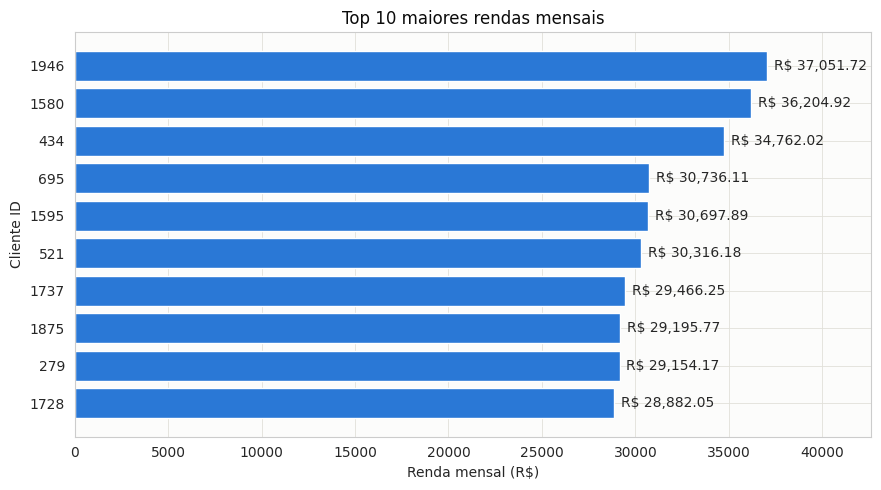

In [ ]:
top10 = df.nlargest(10, 'renda_mensal')[
    ['cliente_id', 'renda_mensal', 'plano', 'segmento_latente']
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    top10['cliente_id'].astype(str),
    top10['renda_mensal'],
    color=PALETTE[1]
)

ax.invert_yaxis()

ax.bar_label(
    bars,
    labels=[f'R$ {x:,.2f}' for x in top10['renda_mensal']],
    padding=5
)

ax.set_xlim(0, top10['renda_mensal'].max() * 1.15)

ax.set_xlabel('Renda mensal (R$)')
ax.set_ylabel('Cliente ID')
ax.set_title('Top 10 maiores rendas mensais')

plt.tight_layout()
plt.show()

* Os 10 maiores valores de renda variam de R$ 28.882 a R$ 37.052;

* Todos pertencem ao segmento “Alto valor”, indicando uma forte concentração das maiores rendas nesse segmento;

* Esses clientes estão principalmente nos planos Básico e Premium, sem ocorrência de VIP entre os 10 maiores;

* Isso sugere que o segmento está mais relacionado às maiores rendas do que o plano contratado.

## 3. Renda e gasto parecem relacionados?

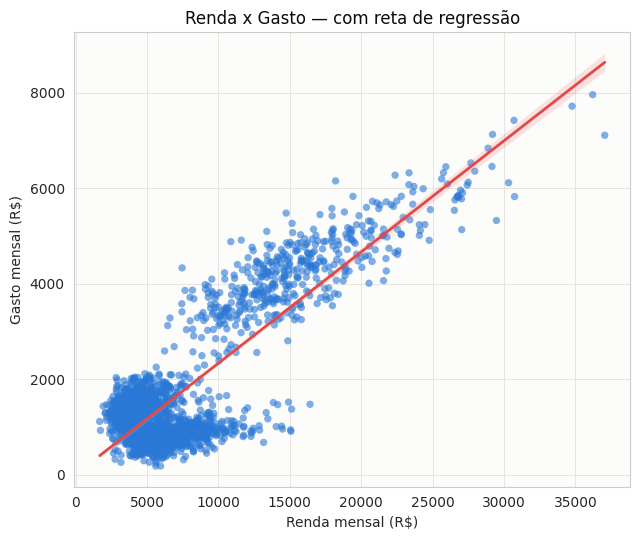

Pearson r = 0.847  (p=0.00e+00)
Spearman r = 0.388  (p=7.09e-73)
Gasto como % da renda — média: 24.8%  desvio: 12.1%


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.regplot(data=df, x='renda_mensal', y='gasto_mensal', ax=ax,
            scatter_kws=dict(s=28, color=PALETTE[1], alpha=0.6, edgecolor='none'),
            line_kws=dict(color=PALETTE[8], linewidth=2))
ax.set_xlabel('Renda mensal (R$)')
ax.set_ylabel('Gasto mensal (R$)')
ax.set_title('Renda x Gasto — com reta de regressão')
plt.tight_layout()
plt.show()

pearson_r, pearson_p = stats.pearsonr(df['renda_mensal'], df['gasto_mensal'])
spearman_r, spearman_p = stats.spearmanr(df['renda_mensal'], df['gasto_mensal'])
print(f"Pearson r = {pearson_r:.3f}  (p={pearson_p:.2e})")
print(f"Spearman r = {spearman_r:.3f}  (p={spearman_p:.2e})")

df['pct_gasto'] = df['gasto_mensal'] / df['renda_mensal']
print(f"Gasto como % da renda — média: {df['pct_gasto'].mean():.1%}  desvio: {df['pct_gasto'].std():.1%}")

* A correlação de Pearson (0,85) indica uma relação linear forte entre renda e gasto;

* A Spearman (0,39) mostra que essa relação é bem mais fraca quando consideramos apenas a ordem dos valores;

* Essa diferença sugere que os clientes de maior renda estão influenciando bastante a correlação, principalmente o segmento “Alto valor”;

* Em média, os clientes gastam 24,8% da renda mensal, mas essa proporção varia bastante (desvio padrão de 12,1 pontos percentuais).

## 4. Os planos possuem comportamentos diferentes?

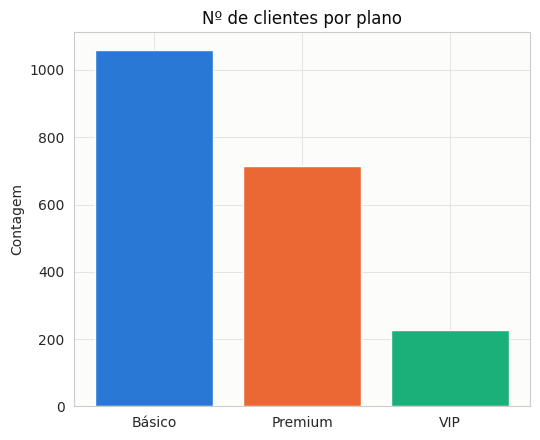

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
counts = df['plano'].value_counts().reindex(plano_order)
ax.bar(counts.index, counts.values, color=CAT_ORDER[:len(plano_order)])
ax.set_title('Nº de clientes por plano')
ax.set_ylabel('Contagem')
plt.tight_layout()
plt.show()

* **Básico**: 1.059 clientes (53%)
* **Premium**: 713 (35,6%)
* **VIP**: 228 (11,4%)

 A base é desbalanceada entre planos, qualquer comparação entre planos precisa levar isso em conta.

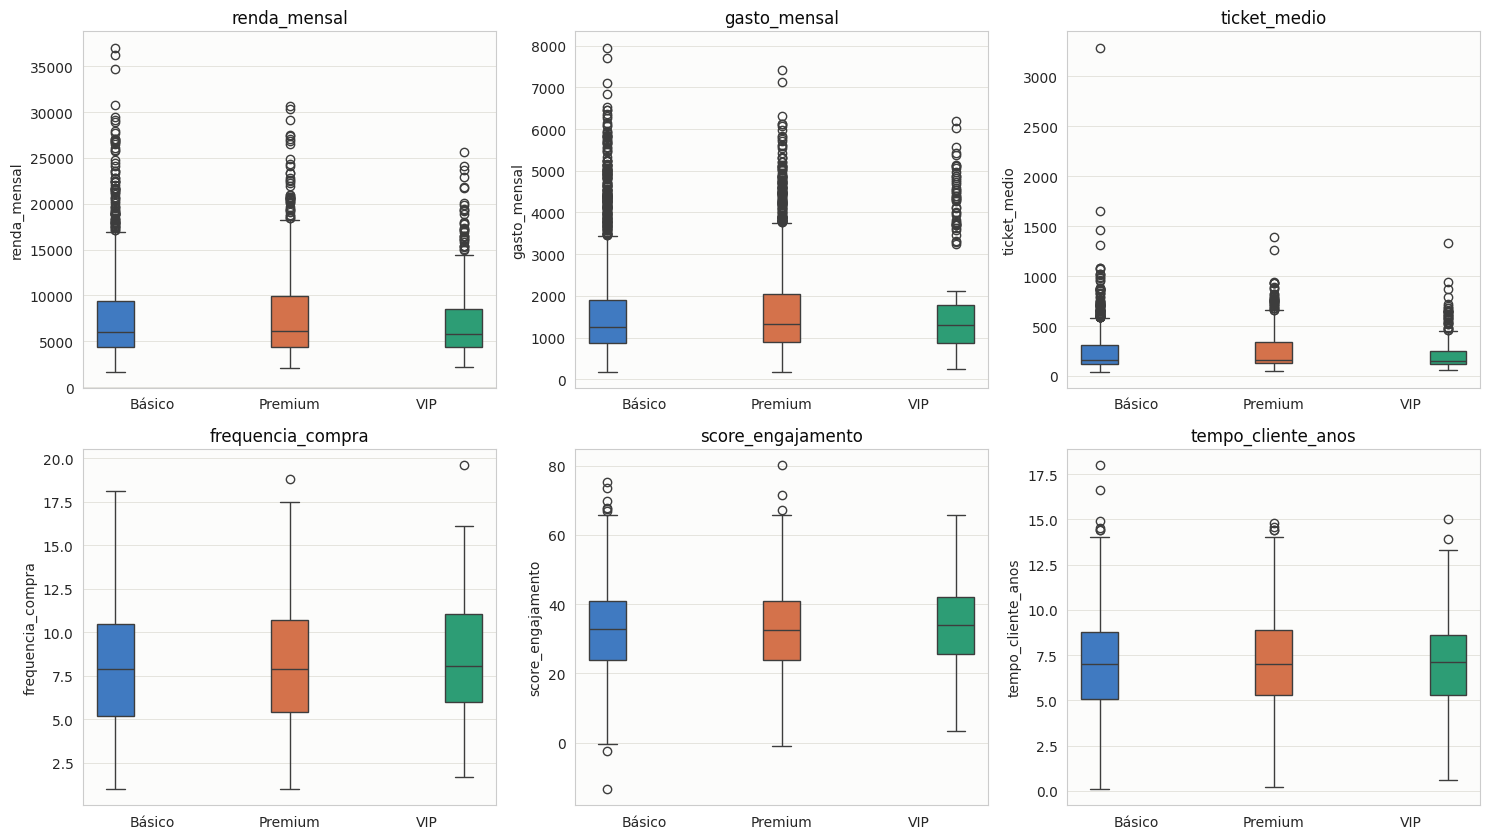

In [ ]:
metricas = ['renda_mensal', 'gasto_mensal', 'ticket_medio', 'frequencia_compra', 'score_engajamento', 'tempo_cliente_anos']

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.flatten()

for i, m in enumerate(metricas):
    sns.boxplot(data=df, x='plano', y=m, order=plano_order, ax=axes[i],
                hue='plano', palette=CAT_ORDER[:len(plano_order)], legend=False)
    axes[i].set_title(m)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
display(df.groupby('plano')[metricas].mean().reindex(plano_order).round(2))

print()
for m in metricas:
    grupos = [df[df['plano'] == p][m] for p in plano_order]
    f, p_anova = stats.f_oneway(*grupos)
    h, p_kruskal = stats.kruskal(*grupos)
    print(f"{m:20s} ANOVA F={f:5.2f} p={p_anova:.4f}   |   Kruskal H={h:5.2f} p={p_kruskal:.4f}")

,renda_mensal,gasto_mensal,ticket_medio,frequencia_compra,score_engajamento,tempo_cliente_anos
plano,,,,,,
Básico,7887.05,1828.24,250.57,8.03,32.48,7.05
Premium,7970.94,1886.69,254.34,8.12,32.78,7.09
VIP,7630.67,1801.03,236.69,8.31,33.76,7.03



renda_mensal         ANOVA F= 0.36 p=0.6961   |   Kruskal H= 0.86 p=0.6499
gasto_mensal         ANOVA F= 0.47 p=0.6223   |   Kruskal H= 1.41 p=0.4931
ticket_medio         ANOVA F= 0.61 p=0.5433   |   Kruskal H= 3.47 p=0.1763
frequencia_compra    ANOVA F= 0.68 p=0.5046   |   Kruskal H= 1.50 p=0.4729
score_engajamento    ANOVA F= 0.97 p=0.3806   |   Kruskal H= 2.25 p=0.3253
tempo_cliente_anos   ANOVA F= 0.05 p=0.9520   |   Kruskal H= 0.19 p=0.9090


* Os três planos apresentam valores de média muito próximos em todas as métricas;

* ANOVA e Kruskal-Wallis indicam p > 0,3 para todas as seis métricas, como todos p > 0,05, a diferença entre os planos não é estatisticamente significativa;

* O `plano` não parece explicar o comportamento dos clientes, o comportamento parece estar mais relacionado ao `segmento_latente` do que ao plano.

## 5. Quais variáveis parecem relacionadas?

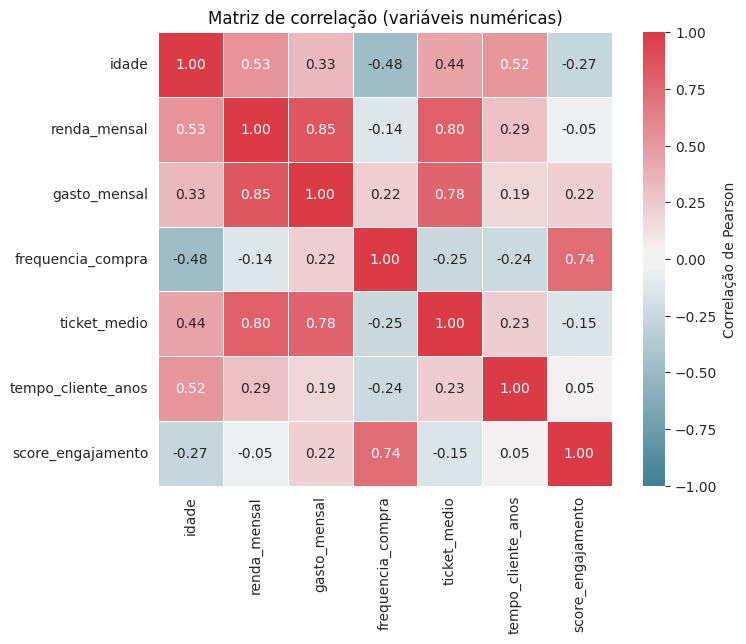

In [ ]:
#Heatmap de correlação entre variáveis numéricas
num_cols = ['idade', 'renda_mensal', 'gasto_mensal', 'frequencia_compra',
            'ticket_medio', 'tempo_cliente_anos', 'score_engajamento']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
cmap = sns.diverging_palette(  
    220, 10, s=75, l=50, sep=10, as_cmap=True
)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.6, linecolor=SURFACE,
            cbar_kws={'label': 'Correlação de Pearson'}, ax=ax)
ax.set_title('Matriz de correlação (variáveis numéricas)')
plt.tight_layout()
plt.show()

* `gasto_mensal`, `renda_mensal` e `ticket_medio`: apresentam correlação forte entre si (0,78 a 0,85);

* `frequencia_compra` × `score_engajamento`: correlação forte (0,74), indicando que clientes que compram mais vezes tendem a ser mais engajados;

* `frequencia_compra` × `ticket_medio`: correlação fraca e negativa (~ -0,25), mostrando que comprar mais vezes não significa gastar mais por compra;

* `idade`: relaciona-se positivamente com `renda_mensal` (0,53), `tempo_cliente_anos` (0,52) e `ticket_medio` (0,44);

* `idade` × `frequencia_compra`/`score_engajamento`: correlações negativas (-0,48 e -0,27), indicando que clientes mais velhos tendem a comprar menos vezes e apresentar menor engajamento.

## 6. Existe alguma estrutura visual escondida?

In [ ]:
features = ['idade', 'renda_mensal', 'gasto_mensal', 'frequencia_compra',
            'ticket_medio', 'tempo_cliente_anos', 'score_engajamento']

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

print('Variância explicada:', pca.explained_variance_ratio_.round(3), '| soma:', pca.explained_variance_ratio_.sum().round(3))

loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1', 'PC2'])
loadings.round(3)

Variância explicada: [0.452 0.283] | soma: 0.735


,PC1,PC2
idade,0.420,-0.225
renda_mensal,0.507,0.181
gasto_mensal,0.431,0.415
frequencia_compra,-0.212,0.616
ticket_medio,0.492,0.103
tempo_cliente_anos,0.281,-0.086
score_engajamento,-0.122,0.589


* Os componentes explicam 73,5% da variância total (PC1 = 45,2% e PC2 = 28,3%);

* **PC1 (*valor do cliente*)**: relacionado principalmente a renda, ticket médio, gasto e idade, representando poder aquisitivo e valor do cliente;

* **PC2 (*atividade/engajamento*)**: associado principalmente à frequência de compra e engajamento, com relação negativa com idade.

A PCA revela dois principais perfis: valor/poder aquisitivo e atividade/engajamento, que juntos explicam 73,5% da variabilidade dos dados.

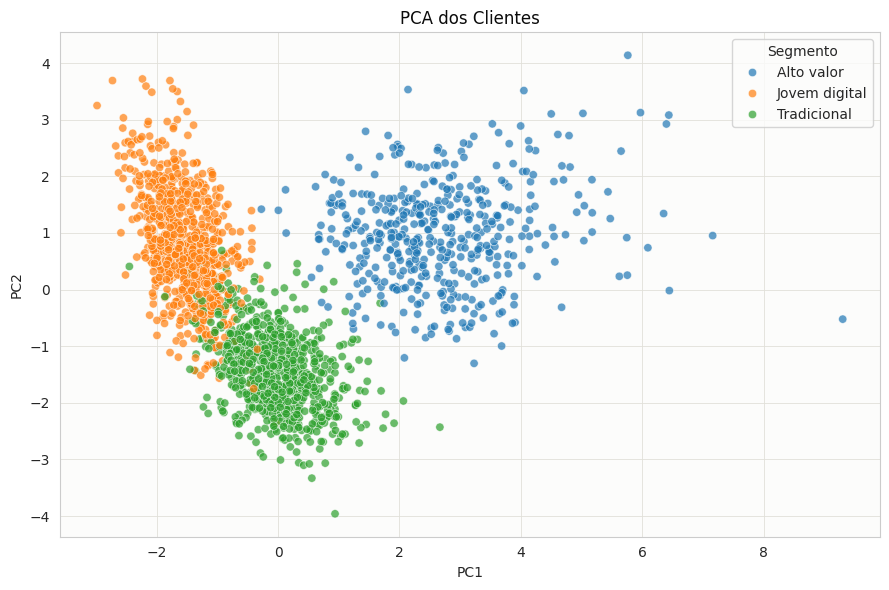

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='pca_1',
    y='pca_2',
    hue='segmento_latente',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA dos Clientes')
plt.legend(title='Segmento')
plt.tight_layout()
plt.show()

## Explorações adicionais

### 1. Distribuição de clientes por canal, região e segmento latente

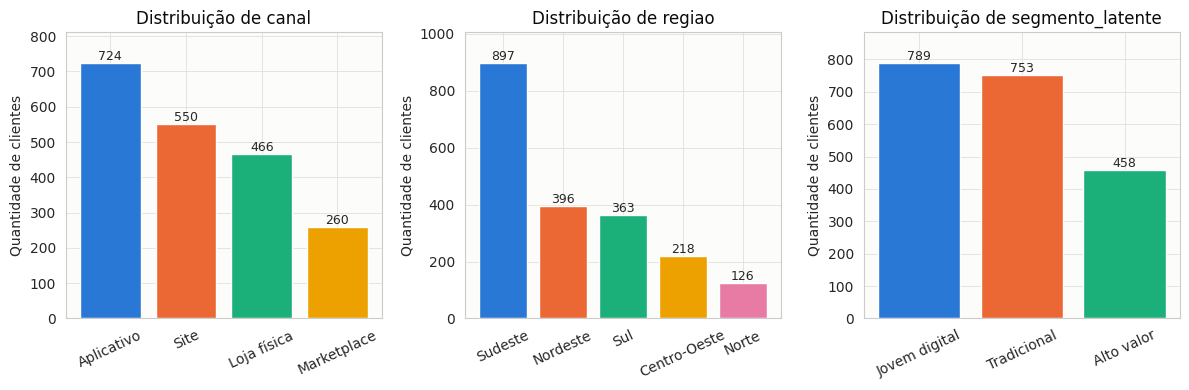

In [ ]:
#Quantidade de clientes por canal, região e segmento latente
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(
    axes,
    ['canal', 'regiao', 'segmento_latente']
):
    
    counts = df[col].value_counts()

    bars = ax.bar(
        counts.index,
        counts.values,
        color=CAT_ORDER[:len(counts)]
    )

    ax.set_title(f'Distribuição de {col}')
    ax.set_ylabel('Quantidade de clientes')
    ax.tick_params(axis='x', rotation=25)

    
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_ylim(0, counts.max() * 1.12)

plt.tight_layout()
plt.show()

* O Aplicativo é o canal mais utilizado (36%), enquanto o Marketplace é o menos utilizado (13%).
* O Sudeste concentra a maior parte dos clientes (45%), enquanto o Norte representa apenas 6%.
* Os segmentos Jovem Digital e Tradicional são os mais representativos (39% e 38%), enquanto Alto Valor corresponde a 23%.

### 2. Evolução dos cadastros ao longo do tempo

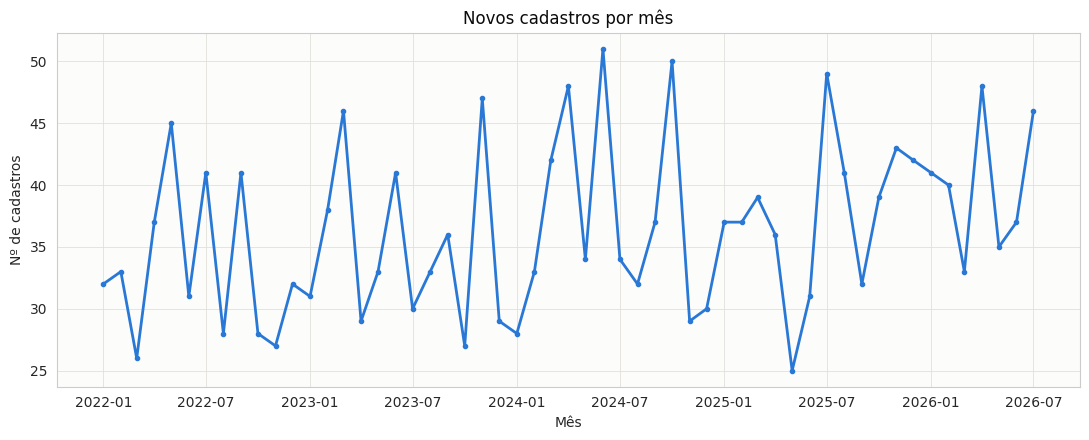

In [ ]:
#Novos cadastros por mês
cadastros_mes = df.set_index('data_cadastro').resample('MS').size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cadastros_mes.index, cadastros_mes.values, color=PALETTE[1], linewidth=2, marker='o', markersize=3)
ax.set_title('Novos cadastros por mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de cadastros')
plt.tight_layout()
plt.show()

* Os dados abrangem janeiro de 2022 a julho de 2026.
* O número de cadastros mensais oscila bastante, entre cerca de 25 e 51 por mês, sem uma tendência de crescimento ou queda visível ao longo do período.
* Os picos e vales se repetem de forma parecida do início ao fim da série, sem um padrão sazonal evidente.

### 3. Frequência de compra x Ticket médio e Engajamento

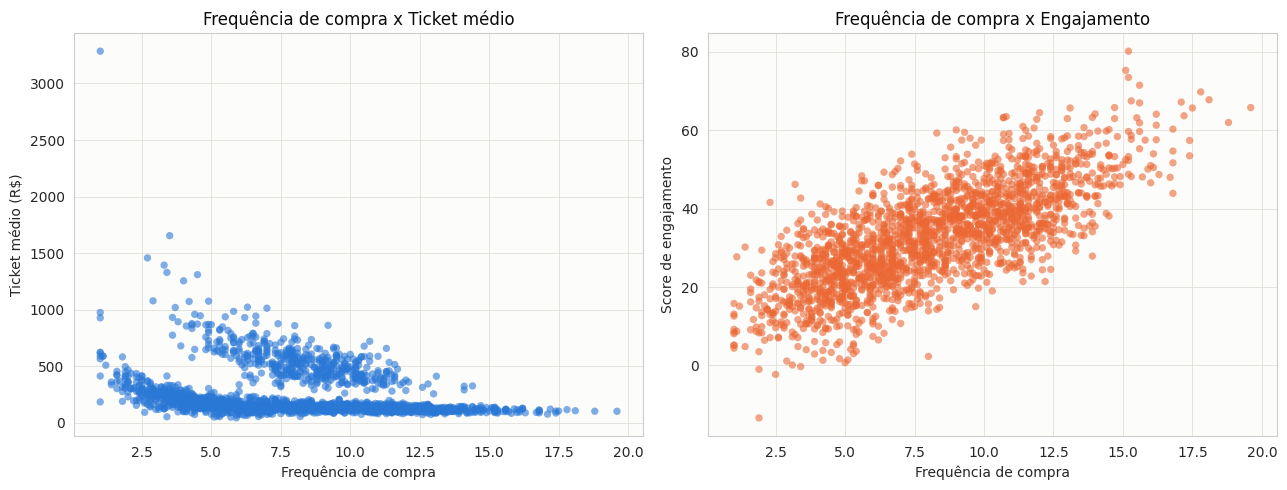

freq x ticket_medio: r=-0.254 (p=0.000)
freq x score_engajamento: r=0.738 (p=0.00e+00)


In [ ]:
#Frequência de compra x Ticket médio e Engajamento
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['frequencia_compra'], df['ticket_medio'], s=28, color=PALETTE[1], alpha=0.6, edgecolor='none')
axes[0].set_xlabel('Frequência de compra')
axes[0].set_ylabel('Ticket médio (R$)')
axes[0].set_title('Frequência de compra x Ticket médio')

axes[1].scatter(df['frequencia_compra'], df['score_engajamento'], s=28, color=PALETTE[2], alpha=0.6, edgecolor='none')
axes[1].set_xlabel('Frequência de compra')
axes[1].set_ylabel('Score de engajamento')
axes[1].set_title('Frequência de compra x Engajamento')

plt.tight_layout()
plt.show()

r1, p1 = stats.pearsonr(df['frequencia_compra'], df['ticket_medio'])
r2, p2 = stats.pearsonr(df['frequencia_compra'], df['score_engajamento'])
print(f"freq x ticket_medio: r={r1:.3f} (p={p1:.3f})")
print(f"freq x score_engajamento: r={r2:.3f} (p={p2:.2e})")

* A frequência de compra e o ticket médio apresentam correlação fraca e negativa (r = -0,25), apesar de estatisticamente significativa (p < 0,001). Isso mostra que significância estatística não significa efeito forte: a relação existe, mas é pequena;

* A frequência de compra e o engajamento apresentam correlação forte (r = 0,74; p < 0,001).Esse resultado reforça a PCA, indicando que frequência e engajamento representam uma dimensão de atividade do cliente.

### 4. Engajamento por canal

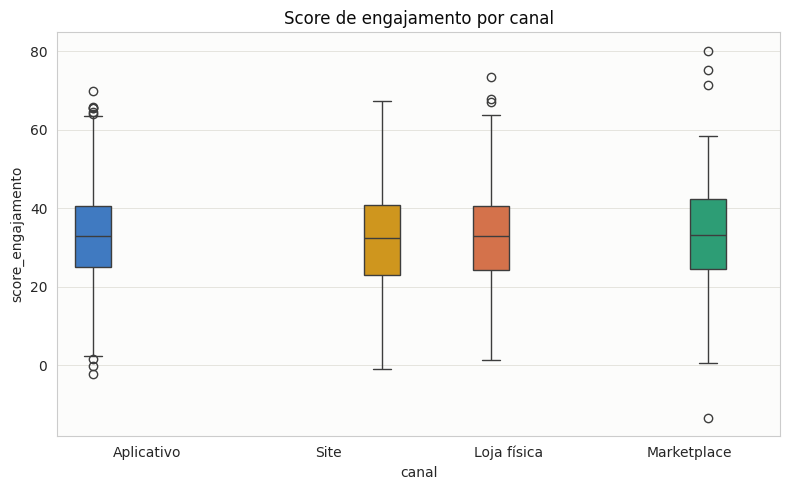

ANOVA engajamento ~ canal: F=0.90  p=0.4407


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='canal', y='score_engajamento',
            order=df['canal'].value_counts().index,
            hue='canal', palette=CAT_ORDER[:df['canal'].nunique()], legend=False, ax=ax)
ax.set_title('Score de engajamento por canal')
plt.tight_layout()
plt.show()

f, p = stats.f_oneway(*[df[df['canal'] == c]['score_engajamento'] for c in df['canal'].unique()])
print(f"ANOVA engajamento ~ canal: F={f:.2f}  p={p:.4f}")

* O Marketplace apresenta o maior engajamento médio (33,4), mas a diferença entre os canais é pequena;

* A ANOVA não encontrou diferença estatisticamente significativa entre os canais (p = 0,44).


### 5. Tempo de cliente x Engajamento, por plano

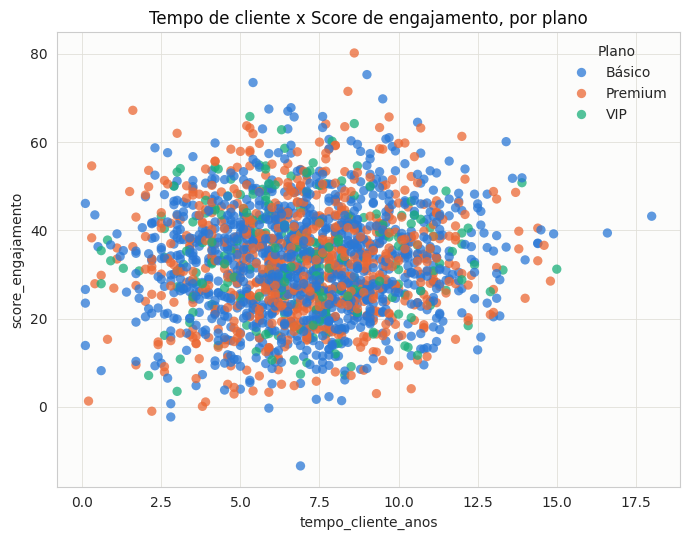

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=df, x='tempo_cliente_anos', y='score_engajamento', hue='plano',
                 hue_order=plano_order, palette=CAT_ORDER[:len(plano_order)], s=45, alpha=0.75, edgecolor='none', ax=ax)
ax.set_title('Tempo de cliente x Score de engajamento, por plano')
ax.legend(title='Plano', frameon=False)
plt.tight_layout()
plt.show()

* Não há uma tendência clara entre tempo de casa e engajamento: clientes antigos e recentes aparecem em diferentes níveis de engajamento.
* Os três planos também ficam misturados, sem separação visual.
* Isso reforça que tempo de casa e engajamento não parecem explicar o plano contratado nesta base.

### 6. Clusterização (KMeans) e validação do segmento_latente

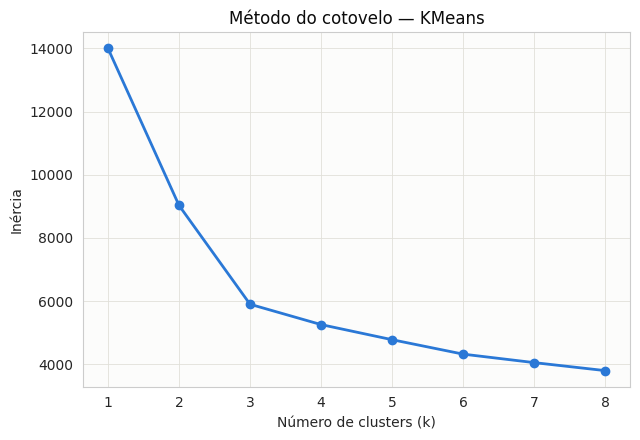

In [ ]:
#Método do cotovelo para escolher k
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(list(k_range), inertias, marker='o', color=PALETTE[1], linewidth=2, markersize=6)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inércia')
ax.set_title('Método do cotovelo — KMeans')
plt.tight_layout()
plt.show()


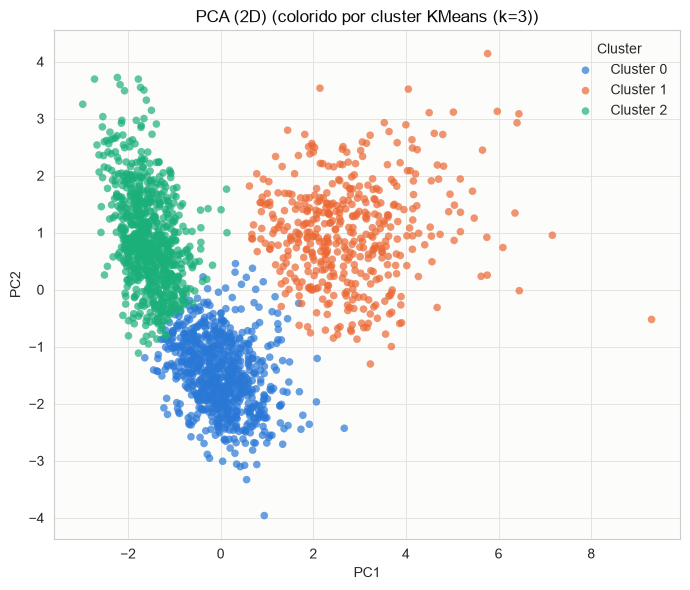

In [34]:
#KMeans com k=3, projetado no espaço da PCA
k_final = 3
km = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['cluster_kmeans'] = km.fit_predict(X_scaled).astype(str)

fig, ax = plt.subplots(figsize=(7, 6))
for i, cat in enumerate(sorted(df['cluster_kmeans'].unique())):
    mask = df['cluster_kmeans'] == cat
    ax.scatter(df.loc[mask, 'pca_1'], df.loc[mask, 'pca_2'],
               s=30, alpha=0.7, edgecolor='none', color=CAT_ORDER[i], label=f'Cluster {cat}')
ax.set_title(f'PCA (2D) (colorido por cluster KMeans (k={k_final}))')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Cluster', frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
#Comparação dos clusters do KMeans com os segmentos já existentes
ct = pd.crosstab(df['cluster_kmeans'], df['segmento_latente'])
display(ct)

ari = adjusted_rand_score(df['segmento_latente'], df['cluster_kmeans'])
print(f"Adjusted Rand Index (cluster KMeans vs segmento_latente): {ari:.3f}")


segmento_latente,Alto valor,Jovem digital,Tradicional
cluster_kmeans,,,
0,10,38,723
1,444,0,0
2,4,751,30


Adjusted Rand Index (cluster KMeans vs segmento_latente): 0.871


* Usando apenas as 7 variáveis numéricas (sem usar `segmento_latente`), o KMeans com k=3 encontra grupos que praticamente reconstroem os segmentos já existentes;

* **Alto Valor**: cluster 100% puro (444 de 444 clientes), capturando 97% dos 458 clientes do segmento;

* **Tradicional**: cluster 94% puro (723 de 771 clientes), capturando 96% dos 753 clientes do segmento;

* **Jovem Digital**: cluster 96% puro (751 de 785 clientes), capturando 95% dos 789 clientes do segmento;

* **ARI = 0,871**: confirma numericamente essa concordância (1,0 seria concordância perfeita, 0 seria aleatório).